In [10]:
import pandas as pd 
import numpy as np 

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.columns.tolist())

KeyboardInterrupt: 

In [ ]:
import ast
import numpy as np

col = "right_wrist_y"  

cell = train[col].iloc[0]
print("Type:", type(cell))
print("Preview:", str(cell)[:120])


Type: <class 'str'>
Preview: [-24.67551166066223, -24.679438799811066, -24.688059690787213, -24.703501324835877, -24.70988730652576, -24.707210233198


In [ ]:
arr = np.array(ast.literal_eval(cell), dtype=float)
print("Parsed array shape:", arr.shape)
print("Num frames:", arr.size)
print("First 5:", arr[:5])
print("Last 5:", arr[-5:])

Parsed array shape: (240,)
Num frames: 240
First 5: [-24.67551166 -24.6794388  -24.68805969 -24.70350132 -24.70988731]
Last 5: [-25.01449429 -25.03238604 -25.01626576 -25.02355414 -25.00919056]


In [ ]:
import numpy as np
import pandas as pd
import ast

def safe_len(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan
    
    if isinstance(v, (list, tuple, np.ndarray)):
        return len(v)
    
    if isinstance(v, str):
        v = v.strip()
        if v.startswith('[') and v.endswith(']'):
            try:
                return len(ast.literal_eval(v))
            except Exception:
                return np.nan
        return np.nan
    
    return np.nan

lengths = train[col].apply(safe_len)

print(lengths.describe())
print("Num bad/unparseable:", lengths.isna().sum())
print("Unique lengths (sample):", sorted(lengths.dropna().astype(int).unique())[:15], "...")


count    332.0
mean     240.0
std        0.0
min      240.0
25%      240.0
50%      240.0
75%      240.0
max      240.0
Name: right_wrist_y, dtype: float64
Num bad/unparseable: 13
Unique lengths (sample): [np.int64(240)] ...


In [ ]:
bad_idx = lengths[lengths.isna()].index
print("Bad rows:", bad_idx.tolist())

for i in bad_idx[:5]:
    v = train[col].iloc[i]
    print(i, "type:", type(v), "value preview:", str(v)[:120])


Bad rows: [53, 64, 93, 101, 118, 131, 141, 160, 193, 205, 252, 315, 344]
53 type: <class 'str'> value preview: [-24.690418595023193, -24.686555753994515, -24.689035770386475, -24.69396977968284, -24.699989652677775, -24.70575478216
64 type: <class 'str'> value preview: [-24.60394252654983, -24.603111689739222, -24.60038562760097, -24.598140586318557, -24.59558792023935, -24.5909933909631
93 type: <class 'str'> value preview: [-24.575855657539115, -24.576212835542893, -24.577088861014765, -24.579176211417003, -24.583447796996893, -24.5883241274
101 type: <class 'str'> value preview: [-24.512661881276415, -24.511958351473655, -24.513498757390824, -24.51452495988509, -24.517200746133152, -24.52046270830
118 type: <class 'str'> value preview: [-24.622454217077305, -24.621422704790326, -24.618604759384315, -24.615727434276977, -24.612260147623545, -24.6080616752


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ast

def parse_ts(v):
    if isinstance(v, str):
        return np.array(ast.literal_eval(v), dtype=float)
    return np.array(v, dtype=float)

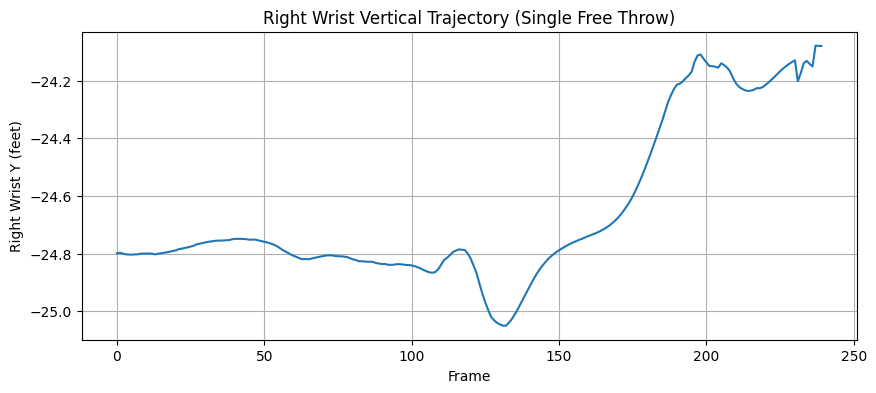

In [ ]:
col = "right_wrist_y"
shot_idx = 230 

ts = parse_ts(train[col].iloc[shot_idx])

plt.figure(figsize=(10, 4))
plt.plot(ts)
plt.xlabel("Frame")
plt.ylabel("Right Wrist Y (feet)")
plt.title("Right Wrist Vertical Trajectory (Single Free Throw)")
plt.grid(True)
plt.show()


In [ ]:
"""
SPLxUTSPAN 2026 — Practical baseline upgrade

What this script does (practical steps):
1) Parse timeseries columns into (n, T) arrays once (fast iteration)
2) Find a per-shot "release-ish" moment by peak RIGHT WRIST speed near the end
3) Extract a window around that moment and compute robust summary features
4) Add a small set of biomechanics angles (elbow/knee/trunk)
5) Train a stronger non-linear model (ExtraTrees) with GroupKFold by participant
6) Evaluate with MSE on SCALED targets (no clipping during CV), clip only for submission

You can run this as-is after adjusting train/test paths.
"""

import ast
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor


# ----------------------------
# Config
# ----------------------------
TRAIN_PATH = "../data/train.csv"
TEST_PATH  = "../data/test.csv"

T = 240

TARGETS = ["angle", "depth", "left_right"]
META = ["id", "shot_id", "participant_id"]

# For evaluation/submission scaling
SCALER_BOUNDS = {
    "angle":      (30, 60),
    "depth":      (-12, 30),
    "left_right": (-16, 16),
}

# Release detection + window
# Search peak wrist speed in last portion of shot to avoid early noise
SEARCH_START = 140      # start frame for release search (tuned: ~last 40% of sequence)
WINDOW_HALF  = 15       # features from [t*-15, t*+15] => ~31 frames window

# If you want to use provided scalers instead of bounds, set these paths and USE_PKL_SCALERS=True
USE_PKL_SCALERS = False
PKL_ANGLE = "/mnt/data/scaler_angle.pkl"
PKL_DEPTH = "/mnt/data/scaler_depth.pkl"
PKL_LR    = "/mnt/data/scaler_left_right.pkl"


# ----------------------------
# Robust parsing: cell -> np.array shape (T,)
# ----------------------------
def to_array(v, T=T) -> np.ndarray:
    """Parse a CSV cell that contains a Python-like list into a (T,) float array."""
    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                arr = np.array(ast.literal_eval(s), dtype=float).flatten()
            except Exception:
                inner = s[1:-1].strip()
                if inner == "":
                    arr = np.zeros(T, dtype=float)
                else:
                    parts = inner.split(",")
                    out = []
                    for p in parts:
                        p = p.strip()
                        try:
                            out.append(float(p))
                        except Exception:
                            out.append(np.nan)
                    arr = np.array(out, dtype=float).flatten()
        else:
            arr = np.zeros(T, dtype=float)
    elif isinstance(v, (list, tuple, np.ndarray)):
        arr = np.array(v, dtype=float).flatten()
    else:
        arr = np.zeros(T, dtype=float)

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

    if arr.size != T:
        fixed = np.zeros(T, dtype=float)
        m = min(arr.size, T)
        fixed[:m] = arr[:m]
        arr = fixed
    return arr


def colname(joint: str, axis: str) -> str:
    return f"{joint}_{axis}"


# ----------------------------
# Scaling helpers
# ----------------------------
def scale_with_bounds(y_raw: np.ndarray, clip: bool) -> np.ndarray:
    """Scale raw targets using provided fixed bounds. Optionally clip to [0,1]."""
    y_scaled = np.zeros_like(y_raw, dtype=float)
    for i, name in enumerate(TARGETS):
        lo, hi = SCALER_BOUNDS[name]
        s = (y_raw[:, i] - lo) / (hi - lo)
        y_scaled[:, i] = np.clip(s, 0, 1) if clip else s
    return y_scaled


def load_pkls():
    with open(PKL_ANGLE, "rb") as f:
        angle_scaler = pickle.load(f)
    with open(PKL_DEPTH, "rb") as f:
        depth_scaler = pickle.load(f)
    with open(PKL_LR, "rb") as f:
        lr_scaler = pickle.load(f)
    return angle_scaler, depth_scaler, lr_scaler


def scale_with_pkls(y_raw: np.ndarray, clip: bool) -> np.ndarray:
    """Scale raw targets using provided pickled MinMax scalers."""
    angle_scaler, depth_scaler, lr_scaler = load_pkls()
    a = angle_scaler.transform(y_raw[:, [0]]).ravel()
    d = depth_scaler.transform(y_raw[:, [1]]).ravel()
    lr = lr_scaler.transform(y_raw[:, [2]]).ravel()
    y_scaled = np.vstack([a, d, lr]).T
    return np.clip(y_scaled, 0, 1) if clip else y_scaled


def scale_targets(y_raw: np.ndarray, clip: bool) -> np.ndarray:
    """Switch between bounds-based scaling and pickle scalers."""
    if USE_PKL_SCALERS:
        return scale_with_pkls(y_raw, clip=clip)
    return scale_with_bounds(y_raw, clip=clip)


# ----------------------------
# Practical step 1: Parse only needed columns ONCE
# ----------------------------
AXES = ["x", "y", "z"]

# Compact joints + anchor
ANCHOR = "mid_hip"

# "Practical" joint list (small but meaningful)
JOINTS = [
    # shooting arm + support arm
    "right_wrist", "right_elbow", "right_shoulder",
    "left_wrist",  "left_elbow",  "left_shoulder",
    # trunk
    "neck", "nose",
    # lower body
    "right_hip", "left_hip",
    "right_knee", "left_knee",
    "right_ankle", "left_ankle",
]

# For angle features (3-point angles)
ANGLE_TRIPLES = [
    ("right_shoulder", "right_elbow", "right_wrist"),  # elbow flexion
    ("left_shoulder",  "left_elbow",  "left_wrist"),
    ("right_hip", "right_knee", "right_ankle"),        # knee flexion
    ("left_hip",  "left_knee",  "left_ankle"),
]

# For trunk "lean" vector
TRUNK_TOP = "neck"
TRUNK_BASE = "mid_hip"


def parse_columns(df: pd.DataFrame, joints: list[str]) -> dict[str, np.ndarray]:
    """
    Returns dict: key = '<joint>_<axis>' => array shape (n, T)
    Only parses requested columns. Much faster than parsing in inner loops.
    """
    needed_cols = []
    for j in set(joints + [ANCHOR, TRUNK_TOP, TRUNK_BASE]):
        for ax in AXES:
            needed_cols.append(colname(j, ax))

    missing = [c for c in needed_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns (examples): {missing[:5]} (total missing={len(missing)})")

    out = {}
    for c in needed_cols:
        out[c] = np.vstack([to_array(v) for v in df[c].values])  # (n, T)
    return out


# ----------------------------
# Practical step 2: Find "release-ish" index per shot
# ----------------------------
def speed_mag(x: np.ndarray, y: np.ndarray, z: np.ndarray) -> np.ndarray:
    """Given (n,T) position arrays, return (n,T-1) speed magnitude using frame diffs."""
    dx = np.diff(x, axis=1)
    dy = np.diff(y, axis=1)
    dz = np.diff(z, axis=1)
    return np.sqrt(dx*dx + dy*dy + dz*dz)


def find_release_indices(arrs: dict[str, np.ndarray]) -> np.ndarray:
    """
    Heuristic: peak RIGHT WRIST speed after SEARCH_START.
    Returns idx shape (n,), indices are in [0, T-2] because speed is length T-1.
    """
    x = arrs[colname("right_wrist", "x")]
    y = arrs[colname("right_wrist", "y")]
    z = arrs[colname("right_wrist", "z")]

    v = speed_mag(x, y, z)  # (n, T-1)
    start = max(0, min(SEARCH_START, v.shape[1]-1))
    rel_seg = v[:, start:]  # (n, ...)
    peak_off = np.argmax(rel_seg, axis=1)
    idx = start + peak_off
    return idx.astype(int)


# ----------------------------
# Practical step 3: Window stats around release + relative-to-anchor
# ----------------------------
def window_slice(A: np.ndarray, center_idx: np.ndarray, half: int) -> np.ndarray:
    """
    Extract per-row window around center index from (n,T) array.
    Returns (n, W) where W = 2*half+1.
    """
    n, T_ = A.shape
    W = 2*half + 1
    out = np.zeros((n, W), dtype=float)

    for i in range(n):
        c = int(center_idx[i])
        # center_idx is based on speed (0..T-2). Use same index for position.
        start = max(0, c - half)
        end = min(T_, c + half + 1)
        w = A[i, start:end]
        # place into out aligned to window start
        out[i, :w.size] = w
    return out


def summarize_window(R: np.ndarray) -> np.ndarray:
    """
    R shape (n,W). Return a compact set of summary stats per row.
    Stats: mean, std, min, max, range, last-first, peak_abs_vel
    """
    mean = R.mean(axis=1)
    std  = R.std(axis=1)
    mn   = R.min(axis=1)
    mx   = R.max(axis=1)
    rng  = mx - mn
    delta = R[:, -1] - R[:, 0]
    # velocity proxy in window
    V = np.diff(R, axis=1)
    peak_abs_vel = np.abs(V).max(axis=1) if V.shape[1] > 0 else np.zeros(R.shape[0])
    return np.vstack([mean, std, mn, mx, rng, delta, peak_abs_vel]).T  # (n,7)


# ----------------------------
# Practical step 4: Add biomechanics angles + trunk lean
# ----------------------------
def angle_3pts(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> np.ndarray:
    """
    Compute angle ABC in radians for arrays a,b,c shape (n,3).
    Robust to zero vectors.
    """
    ba = a - b
    bc = c - b
    nba = np.linalg.norm(ba, axis=1)
    nbc = np.linalg.norm(bc, axis=1)
    denom = np.clip(nba * nbc, 1e-8, None)
    cosang = np.sum(ba * bc, axis=1) / denom
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.arccos(cosang)  # (n,)


def get_xyz_at(arrs: dict[str, np.ndarray], joint: str, t_idx: np.ndarray) -> np.ndarray:
    """Return (n,3) xyz at per-row time index."""
    x = arrs[colname(joint, "x")]
    y = arrs[colname(joint, "y")]
    z = arrs[colname(joint, "z")]
    n = x.shape[0]
    out = np.zeros((n, 3), dtype=float)
    for i in range(n):
        t = int(np.clip(t_idx[i], 0, T-1))
        out[i, 0] = x[i, t]
        out[i, 1] = y[i, t]
        out[i, 2] = z[i, t]
    return out


def trunk_features(arrs: dict[str, np.ndarray], t_idx: np.ndarray) -> np.ndarray:
    """
    Trunk lean: vector (neck - mid_hip) at release.
    Features: (unit vector components), and angle vs vertical (z-axis).
    """
    top  = get_xyz_at(arrs, TRUNK_TOP, t_idx)
    base = get_xyz_at(arrs, TRUNK_BASE, t_idx)
    v = top - base
    nv = np.linalg.norm(v, axis=1, keepdims=True)
    v_unit = v / np.clip(nv, 1e-8, None)

    # angle from vertical: acos( dot(v_unit, [0,0,1]) )
    cos_vert = np.clip(v_unit[:, 2], -1.0, 1.0)  # dot with z-axis = z component
    ang_vert = np.arccos(cos_vert)

    return np.hstack([v_unit, ang_vert.reshape(-1, 1)])  # (n,4)


def angle_features(arrs: dict[str, np.ndarray], t_idx: np.ndarray) -> np.ndarray:
    feats = []
    for A, B, C in ANGLE_TRIPLES:
        a = get_xyz_at(arrs, A, t_idx)
        b = get_xyz_at(arrs, B, t_idx)
        c = get_xyz_at(arrs, C, t_idx)
        ang = angle_3pts(a, b, c)
        feats.append(ang)
    return np.vstack(feats).T  # (n, num_angles)

def smooth_1d(A, k=7):
    # moving average smoothing along time axis
    k = int(k)
    if k <= 1:
        return A
    if k % 2 == 0:
        k += 1  # force odd

    pad = k // 2
    Ap = np.pad(A, ((0, 0), (pad, pad)), mode="edge")
    kernel = np.ones(k, dtype=float) / k
    return np.apply_along_axis(lambda r: np.convolve(r, kernel, mode="valid"), 1, Ap)


def find_dip_indices(
    arrs: dict[str, np.ndarray],
    release_pos_idx: np.ndarray,
    pre_max: int = 80,
    pre_min: int = 20,
) -> np.ndarray:
    z = arrs[colname("mid_hip", "z")]      # (n, T)
    z = smooth_1d(z, k=7)

    n = z.shape[0]
    dip_idx = np.zeros(n, dtype=int)

    for i in range(n):
        r = int(np.clip(release_pos_idx[i], 0, T - 1))

        # window: [r - pre_max, r - pre_min] (inclusive)
        start = max(0, r - pre_max)
        end   = max(start + 1, r - pre_min + 1)   # exclusive slicing end

        seg = z[i, start:end]
        dip_idx[i] = start + int(np.argmin(seg))

    return dip_idx


def segment_stats(pos: np.ndarray, dip_idx: np.ndarray, rel_idx: np.ndarray) -> np.ndarray:
    """
    Compute stats over the segment [dip_idx .. rel_idx] for a (n,T) position array.

    Returns (n, 6) features:
    - mean, std, min, max, delta(end-start), range(max-min)
    """
    n, _ = pos.shape
    out = np.zeros((n, 6), dtype=float)

    for i in range(n):
        a = int(np.clip(dip_idx[i], 0, T - 1))
        b = int(np.clip(rel_idx[i], 0, T - 1))
        if b < a:
            a, b = b, a
        seg = pos[i, a:b+1]  # inclusive
        if seg.size == 0:
            seg = pos[i, [a]]
        out[i, 0] = seg.mean()
        out[i, 1] = seg.std()
        out[i, 2] = seg.min()
        out[i, 3] = seg.max()
        out[i, 4] = seg[-1] - seg[0]
        out[i, 5] = out[i, 3] - out[i, 2]
    return out


def segment_speed_stats(x: np.ndarray, y: np.ndarray, z: np.ndarray,
                        dip_idx: np.ndarray, rel_idx: np.ndarray) -> np.ndarray:
    """
    Speed magnitude stats over segment [dip..rel].
    Returns (n, 5):
    - mean_speed, max_speed, std_speed, impulse_proxy(sum_speed), duration_frames
    """
    n, _ = x.shape
    out = np.zeros((n, 5), dtype=float)

    vx = np.diff(x, axis=1)
    vy = np.diff(y, axis=1)
    vz = np.diff(z, axis=1)
    vmag = np.sqrt(vx*vx + vy*vy + vz*vz)  # (n, T-1)

    for i in range(n):
        a = int(np.clip(dip_idx[i], 0, T - 2))
        b = int(np.clip(rel_idx[i], 0, T - 2))
        if b < a:
            a, b = b, a
        seg = vmag[i, a:b+1]
        if seg.size == 0:
            seg = vmag[i, [a]]
        out[i, 0] = seg.mean()
        out[i, 1] = seg.max()
        out[i, 2] = seg.std()
        out[i, 3] = seg.sum()  # "impulse proxy"
        out[i, 4] = float(b - a + 1)
    return out


def featurize(df: pd.DataFrame) -> np.ndarray:
    n = len(df)
    arrs = parse_columns(df, JOINTS)

    # --- Release anchor (as before) ---
    rel_idx_speed = find_release_indices(arrs)       # 0..T-2
    rel_pos_idx = np.clip(rel_idx_speed, 0, T-1)     # use as pos index

    # --- Dip anchor (new) ---
    dip_pos_idx = find_dip_indices(arrs, rel_pos_idx)

    if all(t in df.columns for t in TARGETS):
        dt = rel_pos_idx - dip_pos_idx
        print("dip->release frames percentiles:",
              np.percentile(dt, [0, 5, 10, 25, 50, 75, 90, 95, 100]))
        print("fraction dt < 5 frames:", (dt < 5).mean())
        print("fraction dt < 0 frames:", (dt < 0).mean())


    # Anchor arrays
    anchor = {ax: arrs[colname(ANCHOR, ax)] for ax in AXES}

    feat_blocks = []

    # (A) Existing: joint relative summaries around release window
    for joint in JOINTS:
        for ax in AXES:
            A = arrs[colname(joint, ax)]
            R = A - anchor[ax]
            W = window_slice(R, rel_pos_idx, WINDOW_HALF)
            S = summarize_window(W)
            feat_blocks.append(S)

    # (B) Existing: mid_hip absolute summaries around release window
    for ax in AXES:
        A = anchor[ax]
        W = window_slice(A, rel_pos_idx, WINDOW_HALF)
        S = summarize_window(W)
        feat_blocks.append(S)

    # (C) Existing: angles + trunk at release
    feat_blocks.append(angle_features(arrs, rel_pos_idx))  # (n,4)
    feat_blocks.append(trunk_features(arrs, rel_pos_idx))  # (n,4)

    # ----------------------------------------------------------
    # (D) NEW: Dip -> Release timing + vertical mechanics features
    # ----------------------------------------------------------

    # Timing feature
    time_dip_to_rel = (rel_pos_idx - dip_pos_idx).astype(float).reshape(-1, 1)
    feat_blocks.append(time_dip_to_rel)

    # Mid-hip vertical movement segment stats (absolute)
    midhip_z = arrs[colname("mid_hip", "z")]
    feat_blocks.append(segment_stats(midhip_z, dip_pos_idx, rel_pos_idx))  # (n,6)

    # Knee extension segment stats (relative to mid_hip, per axis)
    # This captures how legs contribute from dip to release.
    for knee in ["right_knee", "left_knee"]:
        for ax in AXES:
            K = arrs[colname(knee, ax)] - anchor[ax]  # relative to hip
            feat_blocks.append(segment_stats(K, dip_pos_idx, rel_pos_idx))  # (n,6)

    # Wrist speed stats from dip to release (shooting hand)
    rwx = arrs[colname("right_wrist", "x")]
    rwy = arrs[colname("right_wrist", "y")]
    rwz = arrs[colname("right_wrist", "z")]
    feat_blocks.append(segment_speed_stats(rwx, rwy, rwz, dip_pos_idx, rel_idx_speed))  # (n,5)

    # Optional: trunk top speed stats (neck) dip->release (sometimes helps angle/depth)
    nx = arrs[colname("neck", "x")]
    ny = arrs[colname("neck", "y")]
    nz = arrs[colname("neck", "z")]
    feat_blocks.append(segment_speed_stats(nx, ny, nz, dip_pos_idx, rel_idx_speed))  # (n,5)

    X = np.hstack(feat_blocks)
    assert X.shape[0] == n
    return X


# ----------------------------
# Model + CV (GroupKFold)
# ----------------------------
def make_model(n_estimators: int, max_depth, min_samples_leaf: int, random_state=42):
    base = ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1
    )
    return MultiOutputRegressor(base)


def group_cv_search(X, y, groups):
    """
    Small hyperparameter grid (fast + effective).
    Uses scaled MSE (no clipping) to reflect true penalty for out-of-range predictions.
    """
    uniq = np.unique(groups)
    gkf = GroupKFold(n_splits=len(uniq))

    grid = [
        (400, None, 2),
        (800, None, 2),
        (800, 18,   2),
        (800, 18,   4),
        (1200, None, 2),
    ]

    best = {"params": None, "mse": float("inf")}

    y_scaled = scale_targets(y, clip=False)

    for n_estimators, max_depth, min_leaf in grid:
        fold_mses = []
        for (tr_idx, val_idx) in gkf.split(X, y, groups=groups):
            m = make_model(n_estimators, max_depth, min_leaf)
            m.fit(X[tr_idx], y[tr_idx])
            pred = m.predict(X[val_idx])

            pred_scaled = scale_targets(pred, clip=False)
            mse = mean_squared_error(y_scaled[val_idx], pred_scaled)
            fold_mses.append(mse)

        avg = float(np.mean(fold_mses))
        print(f"ETR n={n_estimators:<4} depth={str(max_depth):<4} leaf={min_leaf:<2}  gkf_mse={avg:.6f}  folds={[f'{x:.5f}' for x in fold_mses]}")
        if avg < best["mse"]:
            best = {"params": (n_estimators, max_depth, min_leaf), "mse": avg}

    print("BEST:", best)
    return best["params"]


# ----------------------------
# Main
# ----------------------------
def main():
    print("Loading data...")
    train = pd.read_csv(TRAIN_PATH)
    test  = pd.read_csv(TEST_PATH)

    print("Featurizing train/test (one-time parse + aligned windows)...")
    X_train = featurize(train)
    X_test  = featurize(test)

    y_train = train[TARGETS].values.astype(float)
    groups  = train["participant_id"].values

    print("X_train:", X_train.shape, "X_test:", X_test.shape)
    print("Participants:", np.unique(groups), "count:", len(np.unique(groups)))

    print("\nGroupKFold hyperparam search (fast grid)...")
    n_estimators, max_depth, min_leaf = group_cv_search(X_train, y_train, groups)

    print("\nTraining final model on full training set...")
    final = make_model(n_estimators, max_depth, min_leaf)
    final.fit(X_train, y_train)

    print("Predicting test set...")
    preds_raw = final.predict(X_test)

    # For submission: MUST be scaled and clipped to [0,1]
    preds_scaled = scale_targets(preds_raw, clip=True)

    submission = pd.DataFrame({
        "id": test["id"],
        "scaled_angle": preds_scaled[:, 0],
        "scaled_depth": preds_scaled[:, 1],
        "scaled_left_right": preds_scaled[:, 2],
    })

    submission.to_csv("submission.csv", index=False)
    print("Wrote submission.csv")
    print(submission.head())

    # optional: quick sanity
    mins = submission.drop(columns=["id"]).min().min()
    maxs = submission.drop(columns=["id"]).max().max()
    print(f"Submission scaled range: min={mins:.4f}, max={maxs:.4f}")


if __name__ == "__main__":
    main()


Loading data...
Featurizing train/test (one-time parse + aligned windows)...
dip->release frames percentiles: [ 5.  5.  5.  7. 55. 76. 80. 80. 80.]
fraction dt < 5 frames: 0.0
fraction dt < 0 frames: 0.0
X_train: (345, 376) X_test: (113, 376)
Participants: [1 2 3 4 5] count: 5

GroupKFold hyperparam search (fast grid)...
ETR n=400  depth=None leaf=2   gkf_mse=0.023021  folds=['0.03717', '0.01360', '0.02088', '0.03234', '0.01112']
ETR n=800  depth=None leaf=2   gkf_mse=0.023486  folds=['0.03707', '0.01363', '0.02300', '0.03282', '0.01091']
ETR n=800  depth=18   leaf=2   gkf_mse=0.023490  folds=['0.03710', '0.01369', '0.02299', '0.03276', '0.01091']
ETR n=800  depth=18   leaf=4   gkf_mse=0.023600  folds=['0.03683', '0.01319', '0.02305', '0.03372', '0.01121']
ETR n=1200 depth=None leaf=2   gkf_mse=0.023555  folds=['0.03704', '0.01353', '0.02280', '0.03346', '0.01095']
BEST: {'params': (400, None, 2), 'mse': 0.023020505560659425}

Training final model on full training set...
Predicting tes